# Log–log demand model

From the repository root:

```bash
uv sync
```

MCMC settings in these notebooks use small `draws` / `tune` / `chains` for quick runs. Increase them for production-quality inference.


## Fit, diagnostics, prediction without `quantity`

`LogLogDemandModel` is the baseline: log quantity vs log price with SKU-specific intercept and elasticity.


In [5]:
import warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

from pypricing import LogLogDemandModel, generate_mock_data

df = generate_mock_data(
    n_periods=6 * 52,
    n_skus=10,
    random_state=0,
)

model = LogLogDemandModel()
idata = model.fit(
    df,
    draws=200,
    tune=200,
    chains=2,
    random_seed=42,
    progressbar=False,
    compute_convergence_checks=False,
)

print("Diagnostics:", model.run_diagnostics())
print("fit_summary (head):")
print(model.fit_summary().head())

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma]
Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 4 seconds.


Diagnostics: {'n_divergent': 0, 'max_rhat': 1.02}
fit_summary (head):
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha_sku[0]  4.729  0.047   4.626    4.805      0.002    0.002     442.0   
alpha_sku[1]  4.723  0.081   4.555    4.862      0.004    0.003     375.0   
alpha_sku[2]  5.219  0.071   5.088    5.348      0.003    0.003     420.0   
alpha_sku[3]  4.793  0.072   4.675    4.947      0.003    0.003     509.0   
alpha_sku[4]  2.964  0.116   2.747    3.180      0.005    0.005     465.0   

              ess_tail  r_hat  
alpha_sku[0]     269.0   1.00  
alpha_sku[1]     313.0   1.01  
alpha_sku[2]     297.0   1.00  
alpha_sku[3]     402.0   1.01  
alpha_sku[4]     334.0   1.02  


In [6]:
# Inference groups (compact check; avoids huge HTML repr in git)
list(idata.groups())

['posterior', 'sample_stats', 'observed_data', 'fit_data']

## Predict on new prices without observed `quantity`

Posterior predictive sampling and `predict` only need price (and controls if the model used them).


In [7]:
df_pred = df.drop(columns=["quantity"]).copy()

ppc = model.sample_posterior_predictive(df_pred, random_seed=0)
print("posterior predictive variables:", list(ppc.data_vars))

pred = model.predict(df_pred, hdi_prob=0.9, random_seed=0)
pred.head()

posterior predictive variables: ['log_quantity', 'quantity']


,sku,period,price,log_price,log_quantity,quantity_mean,quantity_hdi_lower,quantity_hdi_upper
0,sku_1,0,2.47,0.9031,4.1431,79.552855,57.575491,98.343820
1,sku_1,1,2.42,0.8831,4.5218,80.793639,58.207692,101.279518
2,sku_1,2,2.44,0.8937,4.6913,80.445904,57.979828,101.676293
3,sku_1,3,2.51,0.9208,4.2627,79.373105,58.703506,101.940684
4,sku_1,4,2.52,0.9236,4.7005,80.143154,58.519056,100.430246


<Axes: title={'center': 'Predicted response for sku=sku_1'}, xlabel='price', ylabel='quantity'>

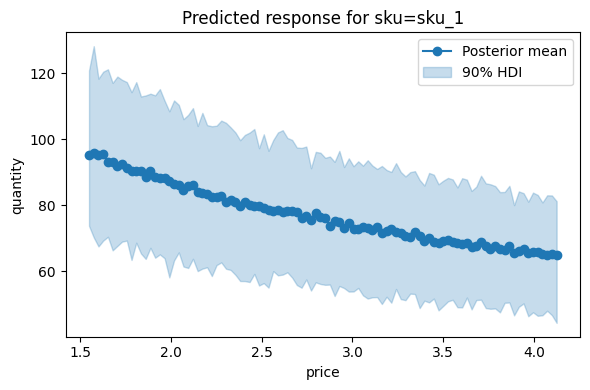

In [8]:
# Response curve for one SKU (posterior mean quantity vs price on a grid)
import numpy as np

sku0 = model.sku_levels_[0]
sub0 = df[df[model.sku_col] == sku0].sort_values(model.price_col)
price_grid = np.linspace(
    float(sub0[model.price_col].min()) * 0.9,
    float(sub0[model.price_col].max()) * 1.1,
    100,
)
controls = (
    {c: float(sub0[c].iloc[0]) for c in model.control_names_}
    if model.control_names_
    else None
)

model.plot_response_curve(
    sku=sku0,
    price_grid=price_grid,
    controls=controls,
    hdi_prob=0.9,
)